In [ ]:
using OrdinaryDiffEq, CairoMakie, Lux
using ProgressTables, StableRNGs, Optimisers, Printf
using Random, Optimization, OptimizationOptimisers, OptimizationOptimJL
using Mooncake
using ForwardDiff
using ComponentArrays: ComponentArray

rng = StableRNG(1234);

# Physics-informed neural networks
Another variant of hybrid models are physics-informed neural networks (PINNs). In a PINN, neural networks are used to learn both the physical parameters of a system, as well as the solution to the system itself. 

A common example for PINNs, is the damped harmonic oscillator system: 

$$ \frac{\mathrm{d}^2 x}{\mathrm{d}t^2} = -\frac{\mu}{m}\frac{\mathrm{d}
x}{\mathrm{d}t} - \frac{k}{m}x $$

Two identifiable quantities in this system are $\delta = \frac{\mu}{2m}$ and the natural frequency $\omega_n = \sqrt{\frac{k}{m}}$.

We will focus here on the underdamped case, where $\delta < \omega_n$.

Setting $\frac{\mathrm{d}x}{\mathrm{d}t} = v$, we can implement the system of ODEs:


In [34]:
function damped_harmonic_oscillator!(du, u, p, t)
    x, v = u
    μ, m, k = p

    du[1] = v
    du[2] = - (μ / m) * v - (k / m) * x
end

damped_harmonic_oscillator! (generic function with 1 method)

Let's simulate some data

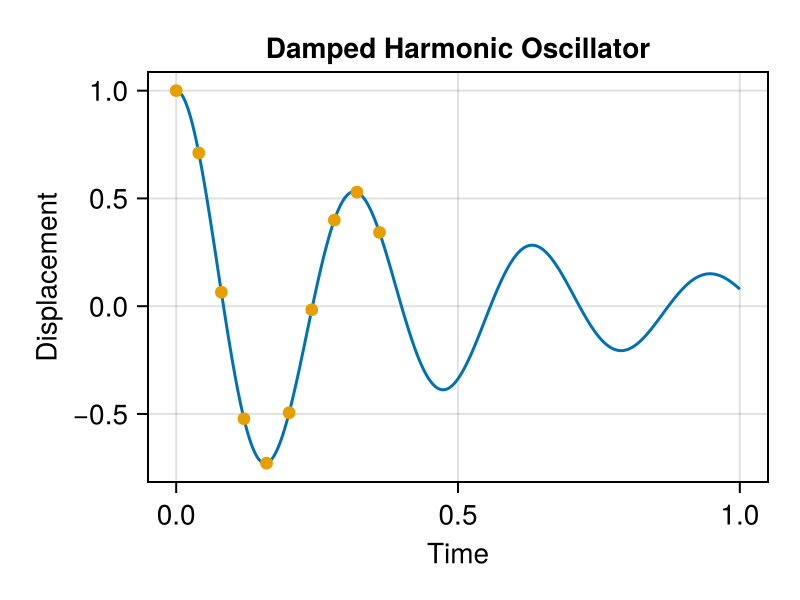

In [35]:
parameters = [2.0, 0.5, 20*20*0.5]  # μ, m, k

# Make sure we are in the underdamped regime (μ/(2m) < sqrt(k/m))
@assert parameters[1]/(2 * parameters[2]) < sqrt(parameters[3]/parameters[2]) "The system is overdamped. Please choose different parameters."
initial_conditions = [1.0, 0.0]  # x₀, v₀

tspan = (0.0, 1.0)

prob = ODEProblem(damped_harmonic_oscillator!, initial_conditions, tspan, parameters)
sol = solve(prob, Tsit5(), saveat=range(0,1,500))


x_data = sol.t[1:20:200]
y_data = sol[1, 1:20:200]

figure_dho = let f = Figure(size=(400,300))
    ax = Axis(f[1, 1], xlabel = "Time", ylabel = "Displacement", title = "Damped Harmonic Oscillator")
    lines!(ax, sol.t, sol[1, :], color = Makie.wong_colors()[1])
    scatter!(ax, x_data, y_data, color = Makie.wong_colors()[2])
    f
end

In [36]:
train_data = (Float32.(x_data'), Float32.(y_data'))
val_data = (Float32.(sol.t[200:20:end]'), Float32.(sol[1, 200:20:end]'))

(Float32[0.3987976 0.43887776 … 0.9599198 1.0], Float32[0.008141761 -0.2937188 … 0.14562382 0.078993894])

## Regular neural network
Now we'll train a regular neural network to learn the solution to the system, given some training data. Let's set up a small neural network and train it on the data we generated above.

In [37]:
network = Chain(
  Dense(1, 32, tanh), Dense(32, 32, tanh), Dense(32, 1)
)

Chain(
    layer_1 = Dense(1 => 32, tanh),               # 64 parameters
    layer_2 = Dense(32 => 32, tanh),              # 1_056 parameters
    layer_3 = Dense(32 => 1),                     # 33 parameters
)         # Total: 1_153 parameters,
          #        plus 0 states.

Set up the training loop

In [38]:
function fit(model, train_data, val_data; epochs=1000, lr=1e-3, rng=StableRNG(1234))

    loss_function = MSELoss()

    ps, st = Lux.setup(rng, model)

    opt = Optimisers.Adam(lr)

    tstate = Training.TrainState(model, ps, st, opt)

    vjp_rule = AutoMooncake()

    pt = IncrementalProgressTable(;
        header=["Epoch", "Train Loss", "Validation Loss"],
        widths=[10, 24, 24],
        format=["%3d", "%.6f", "%.6f"],
        color=[:normal, :normal, :normal],
        border=true,
        alignment=[:center, :center, :center],
    )
    println("Training the model...")
    for epoch in 1:epochs
        _, loss, _, tstate = Training.single_train_step!(vjp_rule, loss_function, train_data, tstate)
        pred_val = Lux.apply(tstate.model, val_data[1], tstate.parameters, Lux.testmode(tstate.states)) |> first
        val_loss = loss_function(pred_val, val_data[2])

        if epoch % 50 == 0 || epoch == 1
                    next(
            pt, [
                epoch, loss, val_loss
            ]
        )
        end

    end
    return tstate
end



fit (generic function with 1 method)

And train the model. We can then visualize the results of the training.

In [39]:
result = fit(network, train_data, val_data; epochs=1000, lr=1e-3)

Training the model...
│      1   │        0.904822        │        0.365991        │
│     50   │        0.280930        │        0.054450        │
│    100   │        0.230426        │        0.205413        │
│    150   │        0.173117        │        0.434353        │
│    200   │        0.113820        │        0.674603        │
│    250   │        0.066757        │        0.752529        │
│    300   │        0.039456        │        0.682138        │
│    350   │        0.026559        │        0.551505        │
│    400   │        0.020312        │        0.446830        │
│    450   │        0.016461        │        0.376768        │
│    500   │        0.013575        │        0.321058        │
│    550   │        0.011253        │        0.270114        │
│    600   │        0.009336        │        0.222735        │
│    650   │        0.007737        │        0.180335        │
│    700   │        0.006392        │        0.145562        │
│    750   │        0.005286     

TrainState(
    Chain(
        layer_1 = Dense(1 => 32, tanh),           # 64 parameters
        layer_2 = Dense(32 => 32, tanh),          # 1_056 parameters
        layer_3 = Dense(32 => 1),                 # 33 parameters
    ),
    number of parameters: 1153
    number of states: 0
    optimizer: Optimisers.Adam(eta=0.001, beta=(0.9, 0.999), epsilon=1.0e-8)
    step: 1000
    cache: TrainingBackendCache(AutoMooncake())
    objective_function: GenericLossFunction
)


In [40]:
params = result.parameters |> cpu_device()

(layer_1 = (weight = Float32[1.178932; -2.6824608; … ; -2.727854; -2.2119682;;], bias = Float32[0.10821972, 0.49390683, 0.31645024, -0.55027956, -0.74685484, 0.103598684, -0.4440432, 0.7526944, 0.13924843, -0.44922253  …  -0.07759788, -0.33454597, 0.06156042, 0.44370076, -0.7478717, -0.5405845, -0.57961166, 0.3015658, 0.43474206, 0.1502514]), layer_2 = (weight = Float32[0.44491565 -0.24228251 … 0.36099756 0.46475428; -0.22042859 0.13750365 … 0.84775513 0.46541917; … ; -0.35773674 0.13186957 … 0.401781 0.118751146; 0.47086576 0.24003842 … 0.45223925 -0.10352627], bias = Float32[0.07805596, -0.029176058, -0.112155855, -0.096791506, -0.10024627, -0.013397947, 0.14623821, -0.13712305, 0.20691107, -0.109583  …  -0.11407861, -0.20796792, 0.029434197, -0.018715814, 0.24806242, -0.1461034, -0.022797992, -0.021942211, -0.1602694, -0.061891932]), layer_3 = (weight = Float32[0.14443713 -0.2838339 … -0.2896633 0.07184895], bias = Float32[0.076043315]))

Let's inspect our NN solution

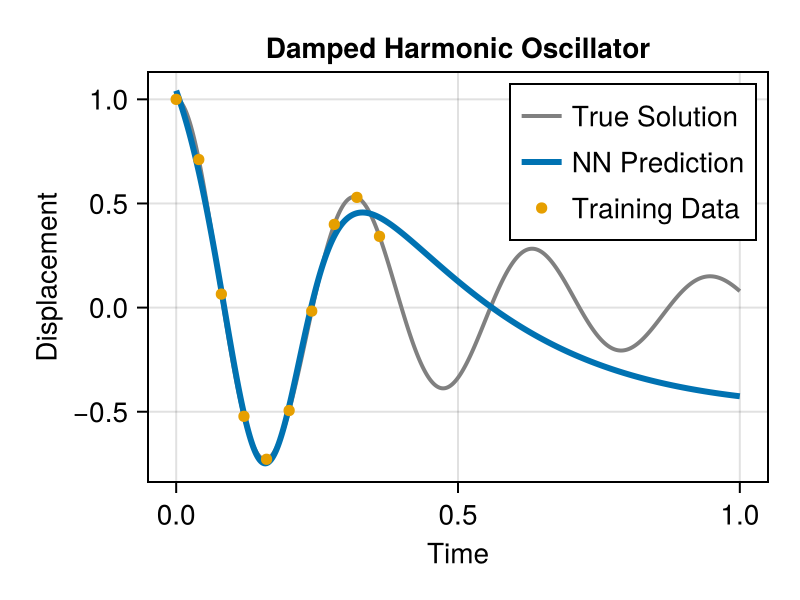

In [41]:
figure_nn_prediction = let f = Figure(size=(400,300))
    ax = Axis(f[1, 1], xlabel = "Time", ylabel = "Displacement", title = "Damped Harmonic Oscillator")
    lines!(ax, sol.t, sol[1, :], color = :gray, label= "True Solution", linewidth=2)

    test_x = Float32.(sol.t')
    test_y = result.model(test_x, params, Lux.testmode(result.states))[1]
    lines!(ax, test_x[1,:], test_y[:], color = Makie.wong_colors()[1], label = "NN Prediction", linewidth=3)

    scatter!(ax, x_data, y_data, color = Makie.wong_colors()[2], label = "Training Data", markersize=8)
    axislegend(ax)
    f
end

It fits the data quite well, but it does not extrapolate well outside of the training data. Let's see if we can do better with a PINN.

## Training a PINN
In a PINN, we will use the same neural network architecture as before, but we will also include the physical parameters of the system as trainable parameters in the model. Besides the regular loss function, we will also include a physics-informed loss function that penalizes the model for violating the physical laws of the system. Because we're also estimating the parameters of the ODE system, the phyics-informed penalty will depend on the parameters as well.

We have:

$$ \mathcal{L}_\text{data} = \frac{1}{N}\sum_{i=1}^{N} \left( x(t_i) - \hat{x}(t_i) \right)^2 $$

With $N$ the number of training data points, $x(t_i)$ the true solution at time $t_i$, and $\hat{x}(t_i)$ the predicted solution at time $t_i$.
And the physics-informed loss function is given by:

$$ \mathcal{L}_\text{physics} = \frac{1}{M}\sum_{j=1}^{M} \left( \frac{\mathrm{d}^2 \hat{x}}{\mathrm{d}t^2}(t_j) + \frac{\mu}{m}\frac{\mathrm{d}\hat{x}}{\mathrm{d}t}(t_j) + \frac{k}{m}\hat{x}(t_j) \right)^2 $$

With $M$ the number of collocation points, and $t_j$ the collocation points. The collocation points are sampled from the time domain of the system, and are used to evaluate the physics-informed loss function.

We combine this as:

$$ \mathcal{L} = \mathcal{L}_\text{data} + \lambda \mathcal{L}_\text{physics} $$



In [42]:
rng = Random.default_rng()
Random.seed!(rng, 0)

chain = Chain(Dense(1, 32, tanh), Dense(32, 32, tanh), Dense(32, 1))
ps, st = Lux.setup(rng, chain) |> f64

((layer_1 = (weight = [-2.5483529567718506; -0.25843119621276855; … ; 2.5465438739047386e-5; -0.17171931266784668;;], bias = [0.3522230386734009, -0.6797136068344116, 0.9589201211929321, 0.0022716522216796875, -0.7389039993286133, -0.962512731552124, -0.297843337059021, 0.7203656435012817, 0.47573137283325195, 0.3112720251083374  …  -0.9438185691833496, 0.16997182369232178, 0.6344934701919556, 0.27660977840423584, 0.7366687059402466, 0.544609785079956, -0.3095238208770752, 0.8767192363739014, -0.9684768915176392, 0.6342960596084595]), layer_2 = (weight = [0.33954647183418274 0.4428443908691406 … -0.4838397800922394 -0.4951406717300415; 0.17026498913764954 0.4802895188331604 … 0.4932977855205536 -0.06824109703302383; … ; 0.3017631769180298 -0.05057412385940552 … 0.02281855046749115 -0.04156191274523735; -0.2469913512468338 -0.2736988067626953 … -0.07399511337280273 0.197324737906456], bias = [-0.1348944455385208, -0.0209666658192873, 0.16606493294239044, -0.1541014164686203, 0.154531508

Define the derivatives

In [52]:
dxdt(x,p) = ForwardDiff.derivative(
x -> chain([x], p, Lux.testmode(st))[1][1], x
)

d2xdt2(x,p) = ForwardDiff.derivative(
x -> dxdt(x,p)[1], x
)

d2xdt2 (generic function with 1 method)

Define the physics-informed loss function

In [101]:
function physics_loss(p_neural, p_ode, chain, x_data)
    # Unpack the ODE parameters
    μ, m, k = p_ode

    # Compute the physics loss over the training data
    physics_losses = typeof(μ)[]
    for x in x_data
        x_val = x[1]
        dxdt_val = dxdt(x_val, p_neural)[1]
        d2xdt2_val = d2xdt2(x_val, p_neural)[1]

        # Compute the residual of the ODE
        residual = d2xdt2_val + (μ / m) * dxdt_val + (k / m) * chain([x_val], p_neural, Lux.testmode(st))[1][1]
        push!(physics_losses, residual^2)
    end

    return sum(physics_losses)/length(physics_losses)
end

function data_loss(p_neural, chain, x_data, y_data)
    # Compute the data loss over the training data
    predictions = [chain([x[1]], p_neural, Lux.testmode(st))[1][1] for x in x_data]
    return sum((predictions .- y_data).^2)/length(y_data)
end

function pinn_loss(p_neural, p_ode, chain, x_data, y_data, coll_x; λ=1.0)
    return data_loss(p_neural, chain, x_data, y_data) + λ * physics_loss(p_neural, p_ode, chain, coll_x)
end

pinn_loss (generic function with 2 methods)

And set up the training loop:

In [134]:
function fit_pinn(chain, p_ode_0, train_data, collocation_points; epochs=1000, lr=1e-3, λ=1.0, rng=StableRNG(1234))

    ps, st = Lux.setup(rng, chain)

    p_init = ComponentArray(
        nn = ps, ode = p_ode_0
    )

    optfunc = Optimization.OptimizationFunction(
        (p, x) -> pinn_loss(p.nn, p.ode, chain, x[1], x[2], collocation_points; λ=λ),
        Optimization.AutoMooncake()
    )

    optprob = Optimization.OptimizationProblem(optfunc, p_init, train_data)
    progress_table = IncrementalProgressTable(;
        header=["Epoch", "Loss"],
        widths=[10, 24],
        format=["%3d", "%.6f"],
        color=[:normal, :normal],
        border=true,
        alignment=[:center, :center],
    )
    iters = 0
    pt_callback(st, loss) = begin
        iters += 1
        if iters % 1000 == 0 || iters == 1
            next(
                progress_table, [
                    iters, loss
                ]
            )
        end
        return false
    end


    optres = Optimization.solve(optprob, Optimisers.Adam(lr), maxiters=epochs, callback=pt_callback)

    optprob_2 = Optimization.OptimizationProblem(optfunc, optres.u, train_data)
    optres_final = Optimization.solve(optprob_2, Optim.BFGS(), maxiters=10_000)
end
    

fit_pinn (generic function with 2 methods)

Let's train the PINN.

In [135]:
pinn_res = fit_pinn(chain, [1.0, 1.0, 1.0], train_data, range(0.0, 1.0, length=30); epochs=5000, lr=1e-4, λ=1e-4)

│      1   │        0.905864        │
│   1000   │        0.223956        │
│   2000   │        0.161007        │
│   3000   │        0.153815        │
│   4000   │        0.148882        │
│   5000   │        0.143233        │


retcode: Success
u: ComponentVector{Float64}(nn = (layer_1 = (weight = [1.6078890006831814; -2.483434630840234; … ; -2.7960682034884665; -1.9152268045731504;;], bias = [-0.3885322767796609, -1.831822794362813, 1.346126331600065, -0.44317263572657756, 0.2416101416731524, 1.150625592489369, -0.492417584791857, 5.372708994907878, -0.4047137367114206, -0.008682593909461158  …  -0.7890293963973325, 1.4145745107642493, 0.12503888997800286, 0.4322537994563194, -1.0475290124685102, -1.929542325351784, -1.146157188224398, 1.754130745701773, -1.0711192006935655, -2.5414402214149017]), layer_2 = (weight = [0.6615040365886546 -0.19587307163250559 … 0.45426529679297506 0.4475486280058246; -0.14421287365692015 -1.183386372047156 … -0.2530919018837778 -0.5155036517603561; … ; -0.5646878187643742 -0.19232988980649393 … 0.6510011915903283 -0.1517520626864438; 0.051498713380769987 0.3743078949776665 … 1.0038671754341482 -0.10655145791151353], bias = [0.29465121529038507, -0.22462247298895452, -0.4862557

And predict the solution using the trained PINN.

In [141]:
pinn_pred = [chain([x[1]], pinn_res.u.nn, Lux.testmode(st))[1][1] for x in Float32.(sol.t')][:];

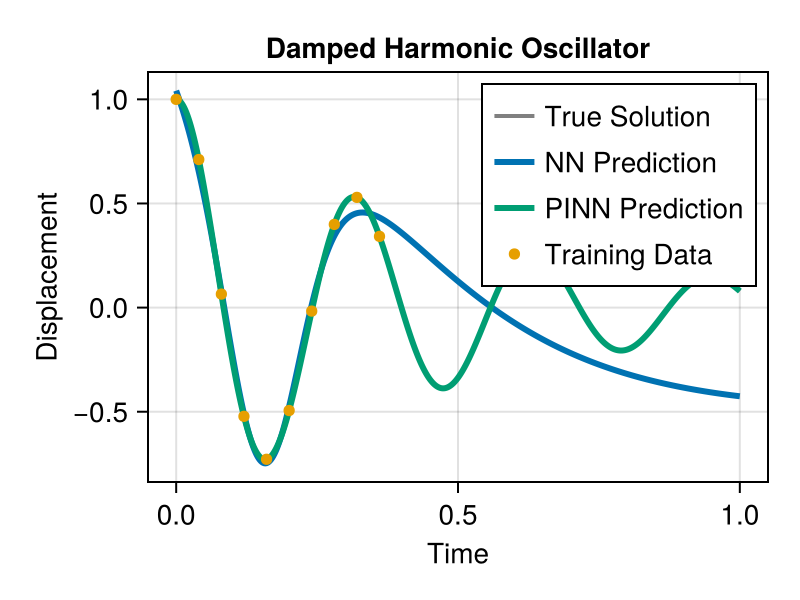

In [137]:
figure_pinn_prediction = let f = Figure(size=(400,300))
    ax = Axis(f[1, 1], xlabel = "Time", ylabel = "Displacement", title = "Damped Harmonic Oscillator")
    lines!(ax, sol.t, sol[1, :], color = :gray, label= "True Solution", linewidth=2)

    test_x = Float32.(sol.t')
    test_y = result.model(test_x, params, Lux.testmode(result.states))[1]
    lines!(ax, test_x[1,:], test_y[:], color = Makie.wong_colors()[1], label = "NN Prediction", linewidth=3)

    lines!(ax, sol.t, pinn_pred, color = Makie.wong_colors()[3], label = "PINN Prediction", linewidth=3)

    scatter!(ax, x_data, y_data, color = Makie.wong_colors()[2], label = "Training Data", markersize=8)
    axislegend(ax)
    f
end

Wow! That's a much better fit than the regular neural network. The PINN is able to extrapolate well outside of the training data. But can we also recover the physical parameters of the system? Let's inspect the learned parameters.

In [143]:
params_pinn = pinn_res.u.ode

println("Original parameters: μ = $(parameters[1]), m = $(parameters[2]), k = $(parameters[3])")
println("Learned parameters: μ = $(params_pinn[1]), m = $(params_pinn[2]), k = $(params_pinn[3])")



Original parameters: μ = 2.0, m = 0.5, k = 200.0
Learned parameters: μ = 0.06672393222216308, m = 0.0166809715279191, k = 6.672610831800352


That's not even close! However, all parameters may not be identifiable from the data. Let's see if we can recover the identifiable parameters $\delta$ and $\omega_n$.

In [ ]:
delta_pinn = params_pinn[1]/(2 * params_pinn[2])
omega_n_pinn = sqrt(params_pinn[3]/params_pinn[2])

println("Original δ = $(parameters[1]/(2 * parameters[2])), ω_n = $(sqrt(parameters[3]/parameters[2]))")
println("Learned δ = $delta_pinn, ω_n = $omega_n_pinn")

Original δ = 2.0, ω_n = 20.0
Learned δ = 2.0000013821283313, ω_n = 20.000333042326304


That's almost perfect! The PINN is able to recover the identifiable parameters of the system, even though it was not trained on them directly. This is a powerful feature of PINNs, as they can learn both the solution to the system and the physical parameters of the system simultaneously.